In [1]:
from google.colab import drive
drive.mount('/content/drive')

from google.colab import files

!cp /content/drive/MyDrive/src/evaluation.py /content/
!pip -q install datasets transformers seqeval scikit-learn pandas accelerate>=1.1.0

Mounted at /content/drive


In [2]:
# test imports
import evaluation

In [3]:
import numpy as np
import pandas as pd
import torch

from collections import Counter

from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    Trainer,
    DataCollatorForTokenClassification
)

from seqeval.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

from datasets import load_from_disk

from evaluation import (
    evaluate_resume_level_standard
)

import warnings
warnings.filterwarnings("ignore")

In [4]:
DATASET_PATH = "/content/drive/MyDrive/resume_ner_hf"

ds = load_from_disk(DATASET_PATH)

# ==================== Label Setup ====================
# label should be manually define BIO tag
label_list = [
    "O",
    "B-JOB_TITLE",
    "I-JOB_TITLE",
    "B-SKILL",
    "I-SKILL",
    "B-EDUCATION",
    "I-EDUCATION",
]

id2label = {i: str(label) for i, label in enumerate(label_list)}
label2id = {str(label): i for i, label in enumerate(label_list)}

print("Data loaded successfully!")
print("Labels:", id2label)

Data loaded successfully!
Labels: {0: 'O', 1: 'B-JOB_TITLE', 2: 'I-JOB_TITLE', 3: 'B-SKILL', 4: 'I-SKILL', 5: 'B-EDUCATION', 6: 'I-EDUCATION'}


In [5]:
MODEL_PATH = "/content/drive/MyDrive/best_bert/"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

model = AutoModelForTokenClassification.from_pretrained(
    MODEL_PATH
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Analysis Trainer

In [6]:
data_collator = DataCollatorForTokenClassification(
    tokenizer=tokenizer
)

trainer = Trainer(
    model=model,
    data_collator=data_collator
)

In [7]:
val_results = evaluate_resume_level_standard(
    trainer=trainer,
    dataset=ds["validation"],
    id2label=id2label,
    stride=128
)

print(val_results["f1"])

0.5659326081188646


In [8]:
test_results = evaluate_resume_level_standard(
    trainer=trainer,
    dataset=ds["test"],
    id2label=id2label,
    stride=128
)

print(test_results["f1"])

0.5996880447747499


In [9]:
final_labels = test_results["final_labels"]
final_preds = test_results["final_preds"]

Per Entity Metrics:

In [10]:
report = test_results["report"]

rows = []

for entity, scores in report.items():

    if not isinstance(scores, dict):
        continue

    if "f1-score" not in scores:
        continue

    rows.append({
        "entity": entity,
        "precision": scores["precision"],
        "recall": scores["recall"],
        "f1": scores["f1-score"],
        "support": scores["support"]
    })

entity_df = pd.DataFrame(rows)

entity_df.sort_values(
    "f1",
    ascending=False
)

,entity,precision,recall,f1,support
1,JOB_TITLE,0.704225,0.746944,0.724956,2209
0,EDUCATION,0.622582,0.662034,0.641703,1799
4,macro avg,0.619157,0.657099,0.637564,10579
3,micro avg,0.582583,0.617828,0.599688,10579
5,weighted avg,0.582535,0.617828,0.599662,10579
2,SKILL,0.530662,0.562319,0.546032,6571


Ground Truth Distribution:

In [11]:
label_counts = Counter()

for seq in final_labels:
    label_counts.update(seq)

distribution_df = pd.DataFrame(
    label_counts.items(),
    columns=["label", "count"]
)

distribution_df.sort_values(
    "count",
    ascending=False
)

,label,count
0,O,263035
2,I-SKILL,7371
1,B-SKILL,6571
6,I-EDUCATION,5254
4,I-JOB_TITLE,3727
3,B-JOB_TITLE,2209
5,B-EDUCATION,1799


Most Common Error:

In [12]:
errors = Counter()

for true_seq, pred_seq in zip(
    final_labels,
    final_preds
):

    for t, p in zip(true_seq, pred_seq):

        if t != p:
            errors[(t, p)] += 1

errors.most_common(30)

[(('O', 'I-SKILL'), 2383),
 (('I-SKILL', 'O'), 2150),
 (('B-SKILL', 'O'), 2063),
 (('O', 'B-SKILL'), 1951),
 (('I-EDUCATION', 'O'), 770),
 (('I-JOB_TITLE', 'O'), 625),
 (('O', 'I-JOB_TITLE'), 575),
 (('O', 'I-EDUCATION'), 568),
 (('B-JOB_TITLE', 'O'), 385),
 (('O', 'B-JOB_TITLE'), 364),
 (('B-EDUCATION', 'O'), 257),
 (('O', 'B-EDUCATION'), 180),
 (('B-SKILL', 'I-SKILL'), 169),
 (('I-SKILL', 'B-SKILL'), 140),
 (('I-SKILL', 'I-EDUCATION'), 119),
 (('B-EDUCATION', 'I-EDUCATION'), 98),
 (('I-EDUCATION', 'B-EDUCATION'), 79),
 (('I-EDUCATION', 'I-SKILL'), 65),
 (('B-SKILL', 'B-EDUCATION'), 59),
 (('I-JOB_TITLE', 'I-SKILL'), 47),
 (('I-SKILL', 'I-JOB_TITLE'), 39),
 (('B-JOB_TITLE', 'I-JOB_TITLE'), 37),
 (('B-EDUCATION', 'B-SKILL'), 33),
 (('B-JOB_TITLE', 'B-SKILL'), 31),
 (('B-SKILL', 'B-JOB_TITLE'), 30),
 (('I-JOB_TITLE', 'B-JOB_TITLE'), 19),
 (('I-JOB_TITLE', 'I-EDUCATION'), 17),
 (('I-EDUCATION', 'I-JOB_TITLE'), 11),
 (('B-SKILL', 'I-EDUCATION'), 9),
 (('B-EDUCATION', 'B-JOB_TITLE'), 6)]

False Negatives:

In [13]:
false_negatives = Counter()

for true_seq, pred_seq in zip(
    final_labels,
    final_preds
):

    for t, p in zip(true_seq, pred_seq):

        if t != "O" and p == "O":
            false_negatives[t] += 1

pd.DataFrame(
    false_negatives.items(),
    columns=["entity", "count"]
).sort_values(
    "count",
    ascending=False
)

,entity,count
1,I-SKILL,2150
0,B-SKILL,2063
5,I-EDUCATION,770
3,I-JOB_TITLE,625
2,B-JOB_TITLE,385
4,B-EDUCATION,257


False Positives:

In [14]:
false_positives = Counter()

for true_seq, pred_seq in zip(
    final_labels,
    final_preds
):

    for t, p in zip(true_seq, pred_seq):

        if t == "O" and p != "O":
            false_positives[p] += 1

pd.DataFrame(
    false_positives.items(),
    columns=["entity", "count"]
).sort_values(
    "count",
    ascending=False
)

,entity,count
1,I-SKILL,2383
0,B-SKILL,1951
5,I-JOB_TITLE,575
2,I-EDUCATION,568
4,B-JOB_TITLE,364
3,B-EDUCATION,180


Confusion Matrix

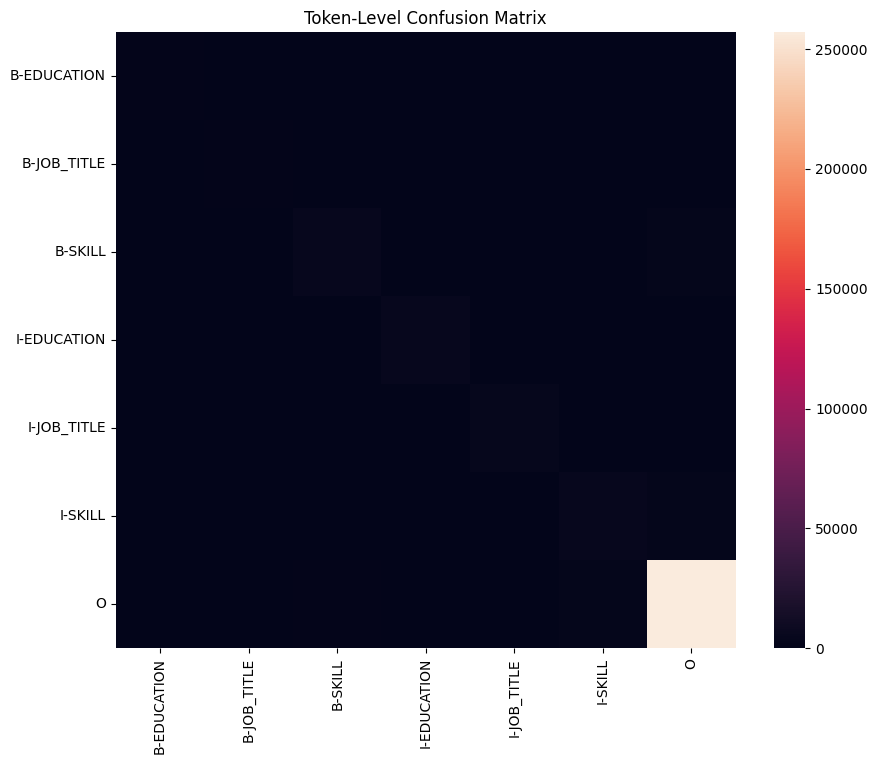

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#----- Flatten Labels -----
y_true = []
y_pred = []

for t_seq, p_seq in zip(
    final_labels,
    final_preds
):
    y_true.extend(t_seq)
    y_pred.extend(p_seq)

#----- Compute Matrix -----
labels = sorted(
    list(
        set(y_true) | set(y_pred)
    )
)

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=labels
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Token-Level Confusion Matrix")
plt.show()